# Кластеризация ЕГЭ (4 если сделаны все задачи)

Рядом лежат данные с координатами точек. Везде используется Евклидово расстояние. Кластером считается набор не менее чем из 30 точек связанных друг с другом. Аномалия это точка находящаяся на расстоянии более 1 от любого кластера.

* Постройте Распределение точек
* Напишите руками DBSCAN и обработайте им все файлы
* Файл 0.xls также решите руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Отметьте Аномалии отдельным цветом
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите два числа - Среднее абсцисс и ординат центроидов кластеров * 100000

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


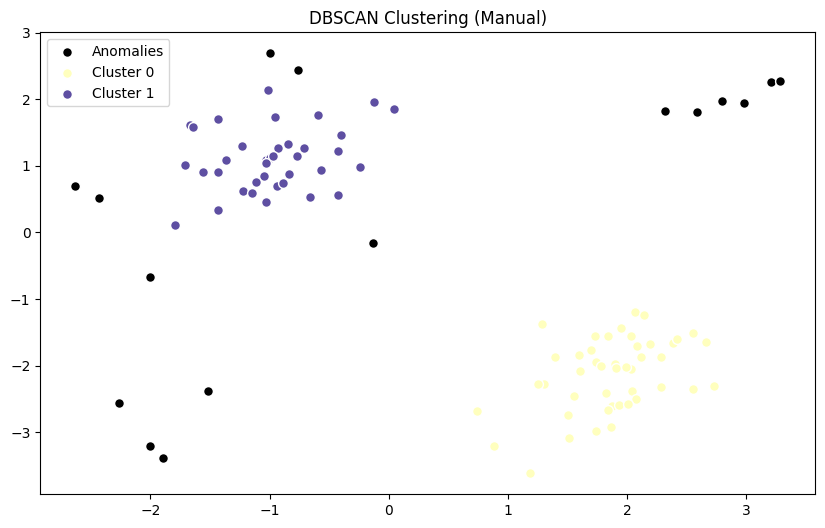

Result: 45531 -46336


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/MachineLearning/task12_anomaly_ege/0.xls')
X = df.values

def manual_dbscan(X, eps, min_samples):
    labels = np.full(X.shape[0], -1)
    cluster_id = 0

    for i in range(X.shape[0]):
        if labels[i] != -1:
            continue

        neighbors = np.where(np.linalg.norm(X - X[i], axis=1) <= eps)[0]

        if len(neighbors) < min_samples:
            continue

        labels[i] = cluster_id
        seeds = list(neighbors)

        idx = 0
        while idx < len(seeds):
            current_point = seeds[idx]
            if labels[current_point] == -1:
                labels[current_point] = cluster_id
                current_neighbors = np.where(np.linalg.norm(X - X[current_point], axis=1) <= eps)[0]
                if len(current_neighbors) >= min_samples:
                    seeds.extend([n for n in current_neighbors if n not in seeds])
            idx += 1
        cluster_id += 1

    return labels

eps = 1.0
min_samples = 30

labels = manual_dbscan(X, eps, min_samples)

plt.figure(figsize=(10, 6))
unique_labels = np.unique(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'k'
        label = 'Anomalies'
    else:
        label = f'Cluster {k}'

    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], label=label, edgecolors='w', s=50)

plt.title('DBSCAN Clustering (Manual)')
plt.legend()
plt.show()

centroids = []
for k in unique_labels:
    if k == -1: continue

    cluster_points = X[labels == k]
    dists = np.sum(np.linalg.norm(cluster_points[:, None] - cluster_points, axis=2), axis=1)
    centroid_idx = np.argmin(dists)
    centroids.append(cluster_points[centroid_idx])

if centroids:
    centroids = np.array(centroids)
    mean_x = np.mean(centroids[:, 0])
    mean_y = np.mean(centroids[:, 1])
    print(f"Result: {int(mean_x * 100000)} {int(mean_y * 100000)}")

# Кластеризация (1 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

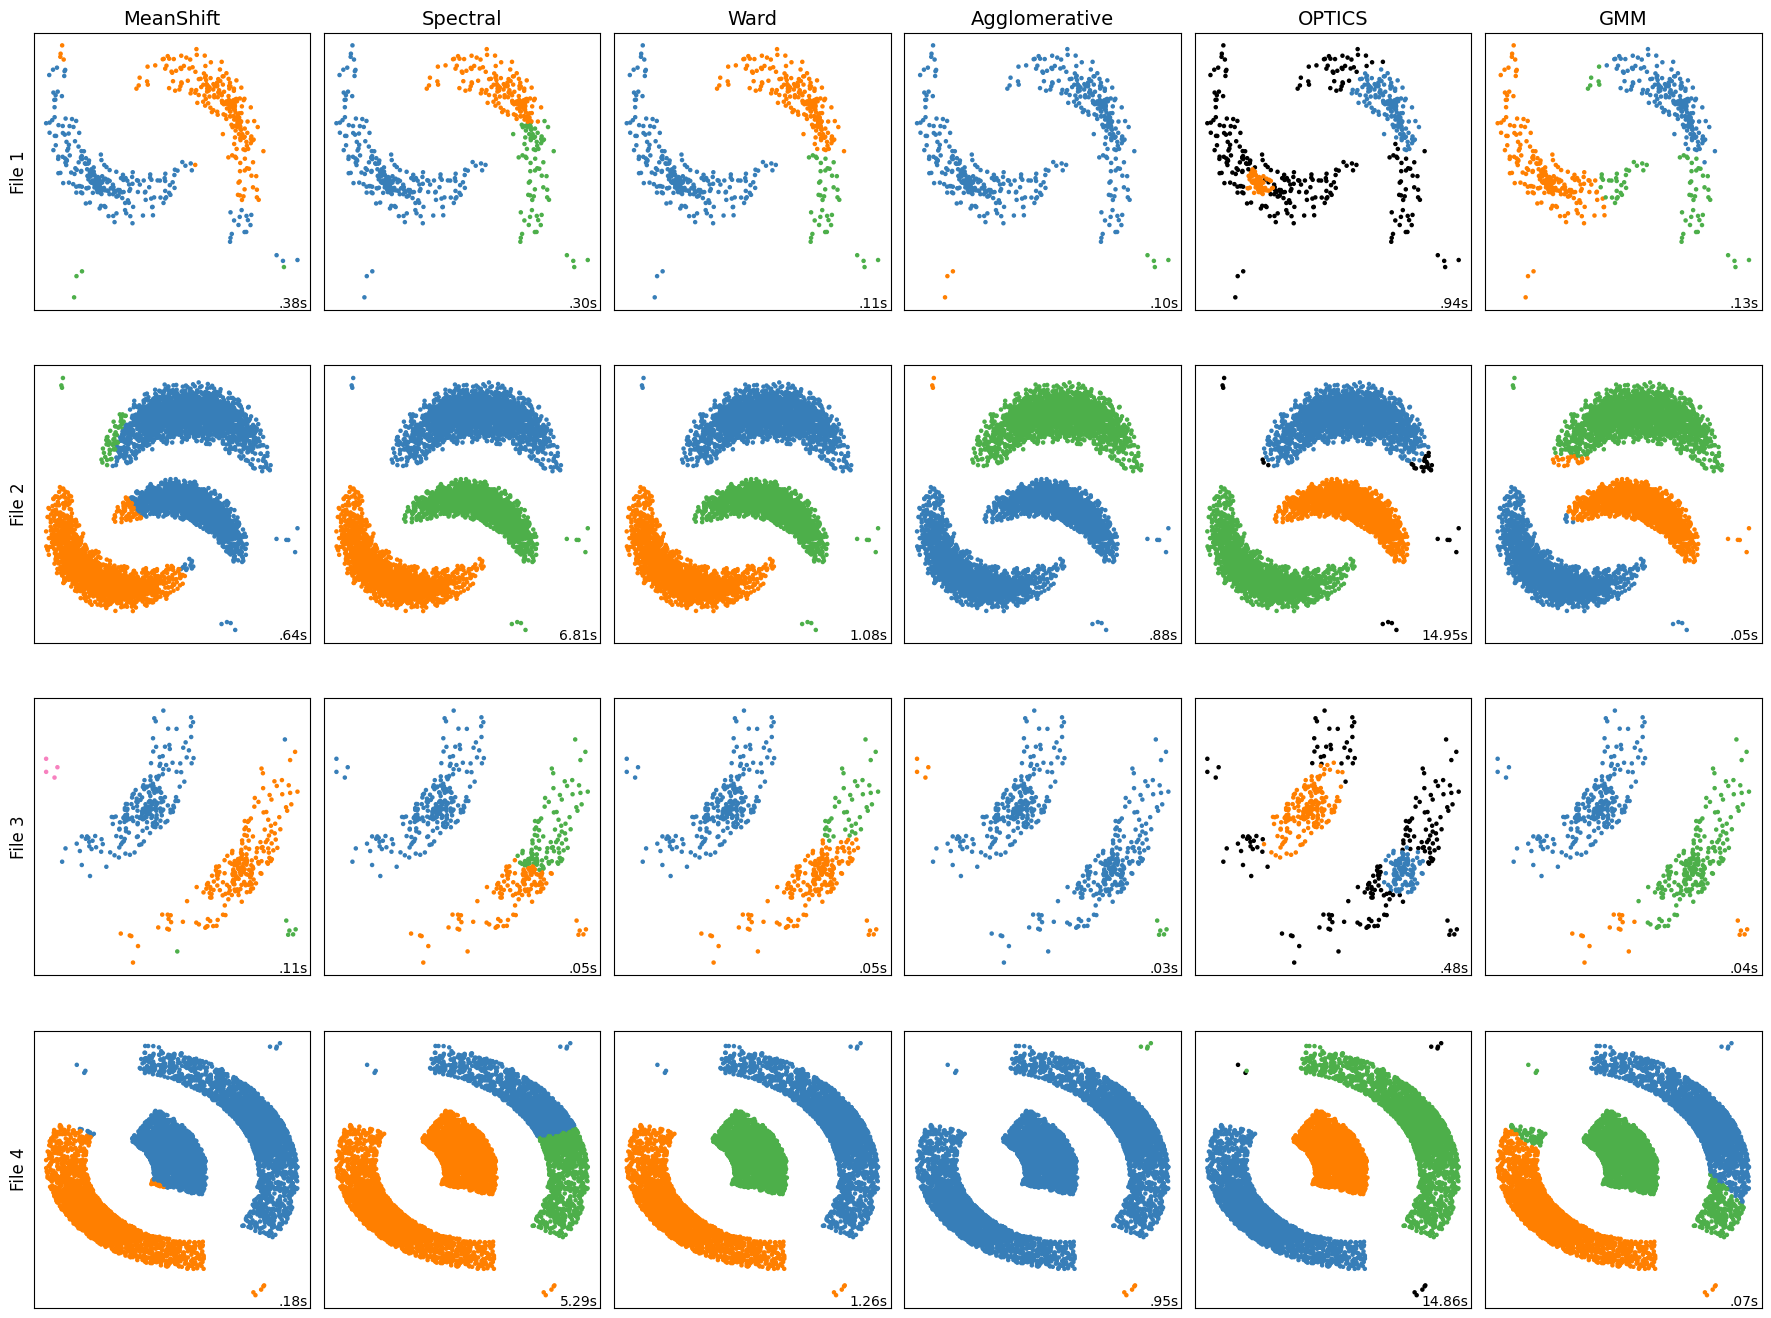

In [17]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle, islice
from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

# 1. ЗАГРУЗКА ДАННЫХ ИЗ ФАЙЛОВ 1.txt - 5.txt
data_list = []
for i in range(2, 6):
    # Убедитесь, что путь к файлам указан верно
    file_path = f'/content/drive/MyDrive/MachineLearning/task12_anomaly_ege/{i}.txt'
    try:
        # Считываем данные. Если в файлах нет заголовков, добавьте names=['X', 'Y']
        df = pd.read_csv(file_path)
        X_data = df.values
        data_list.append((X_data, {"n_clusters": 3}))
    except Exception as e:
        print(f"Ошибка при загрузке {i}.txt: {e}")

# Параметры по умолчанию
default_base = {
    "quantile": 0.3,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

plt.figure(figsize=(18, 15))
plt.subplots_adjust(left=.02, right=.98, bottom=.05, top=.9, wspace=.05, hspace=.2)
plot_num = 1

# 2. ОСНОВНОЙ ЦИКЛ ПО ФАЙЛАМ
for i_dataset, (X, algo_params) in enumerate(data_list):
    params = default_base.copy()
    params.update(algo_params)

    X = StandardScaler().fit_transform(X)

    # Расчет параметров
    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])
    connectivity = kneighbors_graph(X, n_neighbors=params["n_neighbors"], include_self=False)
    connectivity = 0.5 * (connectivity + connectivity.T)

    # 3. ИНИЦИАЛИЗАЦИЯ АЛГОРИТМОВ
    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)

    spectral = cluster.SpectralClustering(
        n_clusters=params['n_clusters'],
        eigen_solver='arpack',
        affinity="nearest_neighbors"
    )

    ward = cluster.AgglomerativeClustering(
        n_clusters=params['n_clusters'],
        linkage='ward',
        connectivity=connectivity
    )

    # ИСПРАВЛЕНО: 'affinity' заменено на 'metric'
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average",
        metric="cityblock",
        n_clusters=params['n_clusters'],
        connectivity=connectivity
    )

    optics = cluster.OPTICS(
        min_samples=params['min_samples'],
        xi=params['xi'],
        min_cluster_size=params['min_cluster_size']
    )

    gmm = mixture.GaussianMixture(
        n_components=params['n_clusters'],
        covariance_type='full'
    )

    clustering_algorithms = (
        ("MeanShift", ms),
        ("Spectral", spectral),
        ("Ward", ward),
        ("Agglomerative", average_linkage),
        ("OPTICS", optics),
        ("GMM", gmm),
    )

    # 4. ВЫПОЛНЕНИЕ И ОТРИСОВКА
    for name, algorithm in clustering_algorithms:
        t0 = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            algorithm.fit(X)
        t1 = time.time()

        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(data_list), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=14)
        if name == "MeanShift":
            plt.ylabel(f"File {i_dataset+1}", size=12)

        colors = np.array(list(islice(cycle(["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628", "#984ea3", "#999999", "#e41a1c", "#dede00"]), int(max(y_pred) + 1))))
        colors = np.append(colors, ["#000000"])

        plt.scatter(X[:, 0], X[:, 1], s=5, color=colors[y_pred])
        plt.xticks(()); plt.yticks(())
        plt.text(.99, .01, ('%.2fs' % (t1 - t0)).lstrip('0'), transform=plt.gca().transAxes, size=10, horizontalalignment='right')
        plot_num += 1

plt.show()